In [1]:
%matplotlib inline
%load_ext autoreload
%autoreload 2

In [2]:
import numpy as np
import numpy.random as npr
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from sklearn.model_selection import KFold
import pickle
from scipy import stats

from imports import *
from config import dir_config
from src.utils import pmf_utils, glm_hmm_utils
import numpy as np
from scipy import sparse
from scipy.optimize import minimize
import matplotlib.pyplot as plt
from typing import Tuple, Dict, List
from tqdm import trange


In [3]:
compiled_dir = Path(dir_config.data.compiled)
processed_dir = Path(dir_config.data.processed)

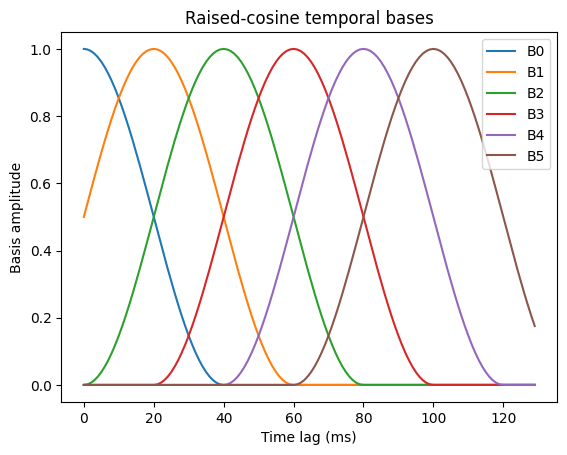

In [4]:
def raised_cosine_basis(n_bases: int, bin_size: float, start_lag_ms: float,
                        end_lag_ms: float, offset_ms: float = 0.0, log_scaled: bool = False):
    # Convert to bin counts
    dt = bin_size
    tmax = int(np.ceil(end_lag_ms / dt))
    times = np.arange(0, tmax) * dt  # ms
    # Nonlinear spacing in log-time often used; but simpler linear spacing is ok
    # We'll use cosine bumps arranged on a log (as typical in Pillow/Park)
    def nonlinear(x):
        return np.log(x + 1e-20)

    def inverse_nonlinear(x):
        return np.exp(x) - 1e-20

    def raised_cosine(timepoints, center, delta):
        """Raised cosine bump centered at `center` with spacing `delta`."""
        arg = (timepoints - center) * np.pi / delta
        arg_clipped = np.clip(arg, -np.pi, np.pi)
        return (np.cos(arg_clipped) + 1) / 2

    if offset_ms < 0:
        raise ValueError("Offset must be non-negative")
    if log_scaled:
        logscaled_yrange = nonlinear(np.array([start_lag_ms, end_lag_ms]) + offset_ms)
        logscaled_spacing = np.diff(logscaled_yrange)[0] / (n_bases - 1)
        logscaled_centers = np.arange(logscaled_yrange[0], logscaled_yrange[1] + logscaled_spacing, logscaled_spacing)
        max_time_bin = inverse_nonlinear(logscaled_yrange[1] + 1.5*logscaled_spacing) - offset_ms
        timepoints = np.arange(0, max_time_bin, dt)
        basis_functions = []
        for c in logscaled_centers:
            basis_functions.append(raised_cosine(nonlinear(timepoints + offset_ms), c, logscaled_spacing))
    else:
        linear_yrange = np.array([start_lag_ms, end_lag_ms]) + offset_ms
        linear_spacing = np.diff(linear_yrange)[0] / (n_bases - 1)
        linear_centers = np.arange(linear_yrange[0], linear_yrange[1] + linear_spacing, linear_spacing)
        max_time_bin = linear_yrange[1] + 1.5*linear_spacing - offset_ms
        timepoints = np.arange(0, max_time_bin, dt)
        basis_functions = []
        for c in linear_centers:
            basis_functions.append(raised_cosine(timepoints + offset_ms, c, 2*linear_spacing))

    basis_functions = np.array(basis_functions).T
    return timepoints, basis_functions

import matplotlib.pyplot as plt
t, B = raised_cosine_basis(n_bases=6, bin_size=1, start_lag_ms=0, end_lag_ms=100, log_scaled=False)
plt.figure()
for i in range(B.shape[1]):
    plt.plot(t, B[:, i], label=f'B{i}')
plt.xlabel('Time lag (ms)')
plt.ylabel('Basis amplitude')
plt.title('Raised-cosine temporal bases')
plt.legend()
plt.show()

In [5]:
import numpy as np

def make_smooth_temporal_basis(filter_type, duration, center_spacing=50, n_bases=None, bin_size=1.0):
    """
    Create smooth temporal basis functions.

    Parameters
    ----------
    shape : str
        'raised cosine' or 'boxcar' (case-insensitive)
    duration : float
        Duration to cover (ms)
    center_spacing : int
        Spacing between basis function centers (ms)

    Returns
    -------
    bases : dict
        {
            'type': "<shape>@make_smooth_temporal_basis",
            'params': {...},          # metadata
            'basis_matrix': ndarray,  # shape (n_time_bins, n_bases)
            'n_bases': int,
            'time_bins': ndarray,     # (n_time_bins, n_bases), zero-indexed
            'centers': ndarray        # center positions for basis functions
        }
    """
    # number of bins in time (ensure integer)
    n_time_bins =  np.ceil(duration / bin_size).astype(int)
    if n_time_bins <= 0:
        raise ValueError("binfun(duration) must return a positive integer number of bins")

    if filter_type == "raised_cosine":
        n_bases = int(np.ceil(duration / center_spacing)) + 1
        time_bins = np.tile(np.arange(1, n_time_bins + 1).reshape(-1, 1), (1, n_bases)).astype(float)
        # spacing and width for raised cosines
        # center_spacing = n_time_bins / float(n_bases-1)
        bump_width = 4.0 * center_spacing
        centers = center_spacing * np.arange(n_bases, dtype=float)

        # compute x = time - center for each basis (broadcasting)
        x = time_bins - centers  # shape (n_time_bins, n_bases)

        # raised-cosine bump
        mask = np.abs(x / bump_width) < 0.5
        basis_matrix = np.where(mask, np.cos(x * 2.0 * np.pi / bump_width) * 0.5 + 0.5, 0.0)

    elif filter_type == "boxcar":
        # n_bases = int(np.ceil(duration / center_spacing))
        time_bins = np.tile(np.arange(1, n_time_bins + 1).reshape(-1, 1), (1, n_bases)).astype(float)

        # box_width = center_spacing
        box_width = n_time_bins / float(n_bases)
        basis_matrix = np.zeros_like(time_bins, dtype=float)
        centers = box_width * (np.arange(1, n_bases + 1, dtype=float)) - box_width / 2.0

        for k in range(n_bases):
            left = np.ceil(box_width * k)
            right = np.ceil(box_width * (k + 1))
            idx = (time_bins[:, k] > left) & (time_bins[:, k] <= right)
            count = idx.sum()
            if count > 0:
                basis_matrix[idx, k] = 1.0 / float(count)  # normalize

    else:
        raise ValueError(f"Unknown basis shape: {filter_type!r}")

    bases = {
        "type": f"{filter_type}@make_smooth_temporal_basis",
        "params": {
            "shape": filter_type,
            "duration": duration,
            "n_bases": n_bases,
        },
        "basis_matrix": basis_matrix,
        "n_bases": basis_matrix.shape[1],
        "time_bins": (time_bins - 1.0),  # zero-indexed times
        "centers": centers
    }

    return bases


In [6]:
import matplotlib.pyplot as plt
def plot_bases(bases, figsize=(8, 5)):
    """
    Plot the basis functions.

    Parameters
    ----------
    bases : dict
        Output of make_smooth_temporal_basis
    figsize : tuple
        Size of the matplotlib figure
    """
    B = bases["basis_matrix"]
    n_time_bins = B.shape[0]
    n_bases = B.shape[1]

    plt.figure(figsize=figsize)
    for k in range(n_bases):
        plt.plot(np.arange(n_time_bins), B[:, k], label=f"Basis {k+1}")
    plt.xlabel("Time bins")
    plt.ylabel("Amplitude")
    plt.title(f"Temporal bases: {bases['params']['shape']}")
    plt.legend()
    plt.tight_layout()
    plt.show()


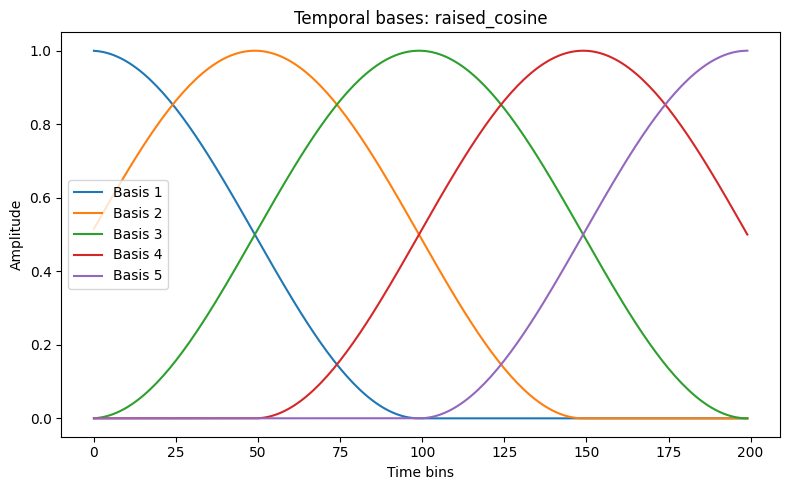

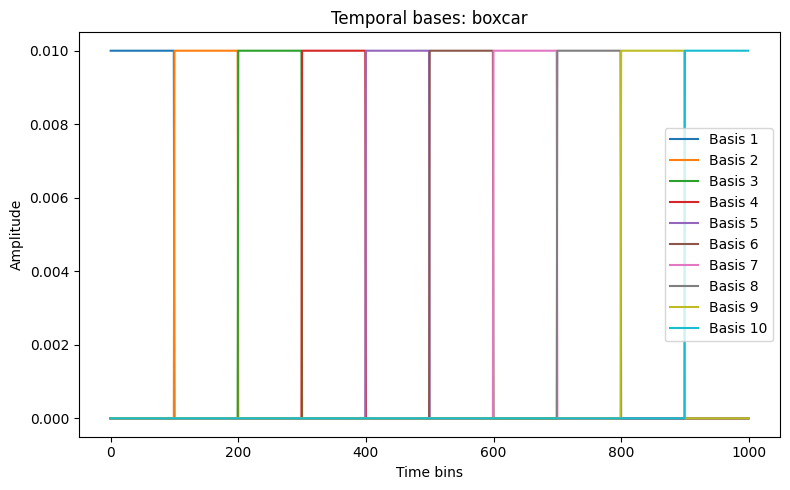

In [11]:

bases = make_smooth_temporal_basis("raised_cosine", duration=200, center_spacing=50, bin_size=1.0)
plot_bases(bases)


bases = make_smooth_temporal_basis("boxcar", duration=100, n_bases=10, bin_size=0.1)
plot_bases(bases)


In [8]:
peak_lag_ms = 10
end_lag_ms = 200
offset_ms = 0.0
n_bases = 6

def nlin(x):
    return np.log(x + 1.0)

cmin = nlin(peak_lag_ms + offset_ms)
cmax = nlin(end_lag_ms + offset_ms)
centers = np.linspace(cmin, cmax, n_bases)


In [9]:
#TODO: 1. Event, trial variable and history basis functions
#TODO: 2. Fit GLM with these basis functions


In [10]:
import numpy as np
from scipy.sparse import csr_matrix

def delta_stim(event_times, n_timebins, values=None):
    """
    Create a sparse delta stimulus vector.

    Parameters
    ----------
    bin_times : array_like of int
        Event times (1-based indices, like MATLAB).
    n_timebins : int
        Total number of bins.
    values : array_like or None
        Values at each event time. Defaults to 1 for each event.

    Returns
    -------
    stim : scipy.sparse.csr_matrix, shape (n_timebins, 1)
        Sparse column vector with impulses at given times.
    """
    event_times = np.asarray(event_times, dtype=int)
    # keep only events within timeline
    valid_mask = event_times <= n_timebins
    event_times = event_times[valid_mask]   # convert 1-based → 0-based

    if values is None:
        values = np.ones(len(event_times), dtype=float)
    else:
        assert len(values) == len(event_times), "Length of values must match number of event times"
        values = np.asarray(values, dtype=float)[valid_mask]



    # row indices = event times, col indices all 0 (single column vector)
    stim = csr_matrix((values, (event_times, np.zeros_like(event_times))),
                      shape=(n_timebins, 1))
    return stim

def boxcar_stim(start_bin, end_bin, n_timebins):
    """
    Create a boxcar stimulus design vector (sparse).

    Parameters
    ----------
    start_bin : int
        Start index
    end_bin : int
        End index
    n_timebins : int
        Total number of bins.

    Returns
    -------
    stim : scipy.sparse.csr_matrix, shape (n_timebins, 1)
        Sparse column vector with ones in the boxcar region.
    """
    # MATLAB is 1-based, Python is 0-based
    idx = np.arange(start_bin, end_bin+1)
    data = np.ones_like(idx, dtype=float)

    stim = csr_matrix((data, (idx, np.zeros_like(idx))), shape=(n_timebins, 1))
    return stim

# Pipeline
#### Event and variable matrix
- Target onset*DeltaStim, Stimulus Onset*BoxcarStim, Saccade*DeltaStim, Bias*BoxcarStim, Y(spiketrain between -50ms from target onset and Saccade)
#### Filters matrix
- Covariates: target_onset (200 ms, 5 bases), 7 * stimulus_onset (500 ms, 11 bases), 2 * Saccade (1500 ms, 31 bases; anti-causal), 2 * Bias (200 ms, 5 bases), post-spike history (10 1ms uniform basis + 10 raised cosine)
#### Convolve event and filter to get design matrix
#### Weighted design matrix to get fitted spike rate
#### Compare with actual spike rate and find best weights

In [16]:
stim_on = lambda timepoints, n_timebins: boxcar_stim(timepoints["stimulus_onset"], timepoints["stimulus_offset"], n_timebins)
target_on = lambda timepoints, n_timebins: delta_stim(timepoints["target_onset"], n_timebins)
saccade_on = lambda timepoints, n_timebins: delta_stim(timepoints["saccade_onset"], n_timebins)
bias_on = lambda timepoints, n_timebins: boxcar_stim(0, n_timebins-1, n_timebins)

covariate_base_dict = {
    "target_onset": (target_on,  "raised_cosine", 200, 5),   # duration (ms), n_bases
    "stimulus_onset": (stim_on, "raised_cosine", 500, 11),
    "saccade_onset": (saccade_on, "raised_cosine", 1500, 31),
    "bias": (bias_on, "raised_cosine", 200, 5),
}


In [ ]:
from scipy.sparse import csr_matrix, vstack
from scipy.signal import convolve
import numpy as np

def compile_design_matrix(trial_indices, timepoints, covariate_base_dict, bin_size=1.0):
    """
    Build a sparse design matrix for GLM from trial event times and covariates.

    Parameters
    ----------
    trial_indices : list or array
        Indices of trials to include.
    timepoints : pandas.DataFrame
        Event times per trial (must include columns like 'target_onset', 'stimulus_onset', etc.).
    covariate_base_dict : dict
        Mapping from covariate name to tuple:
            (event_func, basis_shape, basis_duration, n_bases)
        where:
            - event_func: function(timepoints_row, n_timebins) -> sparse event vector
            - basis_shape: str ('raised_cosine', 'boxcar', etc.)
            - basis_duration: int, duration in ms to cover
            - n_bases: int, number of basis functions
    bin_size : float, default=1.0
        Bin size in ms.

    Returns
    -------
    X : scipy.sparse.csr_matrix
        Sparse design matrix (time x covariates across all trials).
    """
    # total number of columns = sum of basis counts across covariates
    total_basis_dim = sum(n_bases for (_, _, _, n_bases) in covariate_base_dict.values())
    trial_mats = []

    for trial in trial_indices:
        # Align trial times relative to target onset - 50ms
        start_time = timepoints.loc[trial, "target_onset"] - 50
        aligned_tp = timepoints.loc[trial, :].copy() - start_time

        # Duration: from -50ms aligned to target to saccade
        duration = aligned_tp["saccade_onset"] - aligned_tp["target_onset"] + 50
        n_timebins = int(np.ceil(duration / bin_size))

        # Dense matrix for this trial
        miniX = np.zeros((n_timebins, total_basis_dim))
        col_offset = 0

        # Loop through covariates
        for event_func, basis_shape, basis_duration, n_bases in covariate_base_dict.values():
            # Event vector (sparse -> dense)
            event_sparse = event_func(aligned_tp, n_timebins)
            event_vector = np.asarray(event_sparse.toarray()).ravel()

            # Basis functions
            bases = make_smooth_temporal_basis(
                basis_shape, duration=basis_duration, n_bases=n_bases
            )

            # Convolve event with each basis
            conv_matrix = np.zeros((n_timebins, n_bases))
            for j in range(n_bases):
                conv_result = convolve(event_vector, bases["basis_matrix"][:, j], mode="full")
                conv_matrix[:, j] = conv_result[:n_timebins]

            # Insert into trial matrix
            miniX[:, col_offset:col_offset+n_bases] = conv_matrix
            col_offset += n_bases

        trial_mats.append(csr_matrix(miniX))

    # Stack all trials vertically
    return vstack(trial_mats, format="csr")


In [ ]:
"""
neuroGLM_like_pipeline.py

Dependencies: numpy, scipy, matplotlib, tqdm (optional)
This file implements:
 - Raised-cosine basis functions (Park/Pillow style)
 - Design-matrix builders for event-based regressors
 - Spike-history regressors
 - Poisson GLM with analytic gradient and per-block L2 penalty
 - Fit per neuron and reconstruct kernels
"""

import numpy as np
from scipy import sparse
from scipy.optimize import minimize
import matplotlib.pyplot as plt
from typing import Tuple, Dict, List
from tqdm import trange

# ---------------------
# 1) Raised-cosine basis (Park / Pillow style)
# ---------------------


# ---------------------
# 2) Convolution builder: event vector -> design columns via basis
# ---------------------
def event_kernel_design(event_times_idx: np.ndarray, nt: int, basis: np.ndarray) -> np.ndarray:
    """
    event_times_idx: binary vector length nt marking event onset bins (0/1 or counts)
    basis: (n_lags, n_bases)
    Returns: design matrix (nt x n_bases) with event convolved with basis (causal)
    """
    n_lags, n_bases = basis.shape
    X = np.zeros((nt, n_bases))
    # for each basis column, convolve and keep first nt samples (causal)
    for b in range(n_bases):
        # convolution of event vector with basis[:,b]
        # basis is lag increasing rows: basis[lag, b]
        conv = np.convolve(event_times_idx, basis[:, b], mode='full')[:nt]
        X[:, b] = conv
    return X

# ---------------------
# 3) Spike-history design: convolve past spike train with basis (causal: exclude current bin)
# ---------------------
def history_design(spike_counts: np.ndarray, basis: np.ndarray) -> np.ndarray:
    """
    spike_counts: (nt,) integer counts per bin (0/1 typical)
    basis: (n_lags, n_bases)
    Returns design Xhist (nt x n_bases) where each row uses past spikes only:
       i.e., Xhist[t] = sum_{tau>0} spike[t - tau] * basis[tau, :]
    Implementation note: convolve then shift to remove current bin's contribution.
    """
    nt = spike_counts.shape[0]
    n_lags, n_bases = basis.shape
    X = np.zeros((nt, n_bases))
    for b in range(n_bases):
        conv = np.convolve(spike_counts, basis[:, b], mode='full')[:nt]
        # the conv at time t includes spike[t]*basis[0]; to ensure causal history (exclude current),
        # shift conv by 1 bin: X[t] = conv[t-1] ; set X[0]=0
        X[:, b] = np.concatenate(([0.0], conv[:-1]))
    return X

# ---------------------
# 4) Build design matrix for entire trial/concatenated data
# ---------------------
def build_design_matrix(nt: int,
                        events: Dict[str, np.ndarray],
                        spike_counts: np.ndarray,
                        bases: Dict[str, np.ndarray],
                        continuous_regressors: Dict[str, np.ndarray] = None,
                        block_indicator: np.ndarray = None) -> Tuple[np.ndarray, Dict]:
    """
    events: dict with keys like 'cue_onset', 'stim_onset', 'choice_time' -> binary vectors length nt
    bases: dict mapping those keys to basis arrays (n_lags, n_bases) to use for convolution
    continuous_regressors: dict of continuous time series (nt,) e.g. stimulus coherence
    block_indicator: (nt,) vector encoding block membership (e.g., 0 for equal, 1 for unequal) aligned to time bins
    Returns:
        X: design matrix (nt x p)
        meta: dict mapping blocks -> slice indices and human-readable info for reconstructing kernels
    """
    blocks = []
    meta = {'names': [], 'slices': []}
    # For each event name in events, convolve with its basis
    for name, evvec in events.items():
        if name not in bases:
            raise ValueError(f"No basis provided for {name}")
        X_block = event_kernel_design(evvec, nt, bases[name])
        blocks.append(X_block)
        meta['names'].append(name)
        start = sum(b.shape[1] for b in blocks[:-1]) if len(blocks) > 1 else 0
        meta['slices'].append((start, start + X_block.shape[1]))
    # continuous regressors (modulated by basis or direct)
    if continuous_regressors is not None:
        for name, series in continuous_regressors.items():
            # optionally convolve with basis if provided
            if name in bases:
                # treat series as continuous "event amplitude" (multiply basis conv by series)
                # simplest: convolve series with each basis directly
                Xc = np.zeros((nt, bases[name].shape[1]))
                for b in range(bases[name].shape[1]):
                    Xc[:, b] = np.convolve(series, bases[name][:, b], mode='full')[:nt]
                blocks.append(Xc)
                meta['names'].append(name)
                start = sum(b.shape[1] for b in blocks[:-1])
                meta['slices'].append((start, start + Xc.shape[1]))
            else:
                # raw (nt x 1)
                blocks.append(series[:, None])
                meta['names'].append(name)
                start = sum(b.shape[1] for b in blocks[:-1])
                meta['slices'].append((start, start + 1))
    # block indicator: include as a regressor or interact with other blocks
    if block_indicator is not None:
        # direct indicator column
        blocks.append(block_indicator[:, None])
        meta['names'].append('block_indicator')
        start = sum(b.shape[1] for b in blocks[:-1])
        meta['slices'].append((start, start + 1))
    # spike history
    if 'history' in bases:
        Xhist = history_design(spike_counts, bases['history'])
        blocks.append(Xhist)
        meta['names'].append('history')
        start = sum(b.shape[1] for b in blocks[:-1])
        meta['slices'].append((start, start + Xhist.shape[1]))
    # Concatenate
    if len(blocks) == 0:
        X = np.zeros((nt, 0))
    else:
        X = np.concatenate(blocks, axis=1)
    return X, meta

# ---------------------
# 5) Poisson GLM with per-block L2 penalty
# ---------------------
class PoissonGLM:
    def __init__(self, fit_intercept: bool = True, block_penalty: Dict[str, float] = None, meta: Dict = None):
        """
        block_penalty: dict mapping meta['names'] entries -> penalty scalar (L2)
        meta: the meta dictionary returned by build_design_matrix (used to map penalties to parameters)
        """
        self.fit_intercept = fit_intercept
        self.block_penalty = block_penalty or {}
        self.meta = meta or {'names': [], 'slices': []}
        self.coef_ = None
        self.res = None

    def _add_intercept(self, X):
        n = X.shape[0]
        return np.hstack((np.ones((n,1)), X))

    def _penalty_diag(self):
        # build diagonal penalty vector (length p)
        p = sum((s[1] - s[0]) for s in self.meta['slices'])
        if self.fit_intercept:
            p += 1
        pen = np.zeros(p)
        offset = 1 if self.fit_intercept else 0
        for name, (start, end) in zip(self.meta['names'], self.meta['slices']):
            val = self.block_penalty.get(name, 0.0)
            pen[offset + start: offset + end] = val
        return pen

    def _negloglik_and_grad(self, beta, X, y, offset):
        if self.fit_intercept:
            # beta[0] intercept
            lin = X.dot(beta) + offset
        else:
            lin = X.dot(beta) + offset
        # clip for stability
        lin = np.clip(lin, -50, 50)
        lam = np.exp(lin)
        nll = - np.sum(y * lin - lam)
        # L2 penalty per-parameter (diagonal)
        pen = self._penalty_diag()
        if pen.sum() > 0:
            nll += 0.5 * np.sum(pen * (beta**2))
        grad = - X.T.dot(y - lam)
        if pen.sum() > 0:
            grad += pen * beta
        return nll, grad

    def fit(self, X, y, offset=None, beta0=None, options=None):
        if offset is None:
            offset = np.zeros(X.shape[0])
        self.X = X.copy()
        self.y = y.copy()
        if self.fit_intercept:
            Xuse = self._add_intercept(X)
        else:
            Xuse = X
        if beta0 is None:
            beta0 = np.zeros(Xuse.shape[1])
            if self.fit_intercept:
                mu = max(1e-6, y.mean())
                beta0[0] = np.log(mu)
        def fun(b):
            nll, _ = self._negloglik_and_grad(b, Xuse, y, offset)
            return nll
        def jac(b):
            _, g = self._negloglik_and_grad(b, Xuse, y, offset)
            return g
        if options is None:
            options = {'maxiter':1000}
        res = minimize(fun, beta0, jac=jac, method='L-BFGS-B', options=options)
        self.coef_ = res.x
        self.res = res
        return res

    def predict_rate(self, X, offset=None):
        if offset is None:
            offset = np.zeros(X.shape[0])
        if self.fit_intercept:
            Xuse = self._add_intercept(X)
        else:
            Xuse = X
        lin = Xuse.dot(self.coef_) + offset
        lin = np.clip(lin, -50, 50)
        return np.exp(lin)

# ---------------------
# 6) Example synthetic pipeline (replace with real data)
# ---------------------
def example_pipeline():
    # synthetic time series length (concatenate trials)
    nt = 5000
    bin_ms = 10.0
    # Make synthetic events
    cue = np.zeros(nt)
    stim = np.zeros(nt)
    choice = np.zeros(nt)
    # generate random trial onsets every 250 bins
    rng = np.random.RandomState(1)
    trial_onsets = np.arange(100, nt-100, 250)
    n_trials = len(trial_onsets)
    # For each trial, set cue at onset, stim for 100 bins, choice at onset+150
    stim_strength = np.zeros(nt)
    block_indicator = np.zeros(nt)  # 0 = equal, 1 = unequal
    for i, t0 in enumerate(trial_onsets):
        cue[t0] = 1
        stim[t0+5:t0+5+50] = 1  # square pulse stimulus (50 bins)
        # modulate stimulus strength randomly and by block (simulate prior)
        coh = rng.randn() * 0.5 + (0.5 if (i % 2 == 0) else 0.0)
        stim_strength[t0+5:t0+5+50] *= coh
        # choice time
        choice[t0+150] = 1
        if (i % 2) == 1:
            # mark half the trials as 'unequal prior'
            block_indicator[t0:t0+250] = 1.0
    # create spike train for one neuron using ground-truth kernels
    # define bases
    B_stim, t_stim = raised_cosine_basis(n_bases=6, bin_size=bin_ms, peak_lag_ms=10, end_lag_ms=300)
    B_cue, _ = raised_cosine_basis(n_bases=4, bin_size=bin_ms, peak_lag_ms=10, end_lag_ms=200)
    B_choice, _ = raised_cosine_basis(n_bases=4, bin_size=bin_ms, peak_lag_ms=10, end_lag_ms=200)
    B_hist, _ = raised_cosine_basis(n_bases=5, bin_size=bin_ms, peak_lag_ms=5, end_lag_ms=200, offset_ms=1)
    bases = {'stim': B_stim, 'cue': B_cue, 'choice': B_choice, 'history': B_hist}
    events = {'cue': cue, 'stim': (stim>0).astype(float), 'choice': choice}
    continuous = {'stim_strength': stim_strength}
    # Build a placeholder spike train by simulating a Poisson process with known kernels
    # true weights (random)
    w_cue = np.random.randn(B_cue.shape[1]) * 0.8
    w_stim = np.random.randn(B_stim.shape[1]) * 0.6
    w_choice = np.random.randn(B_choice.shape[1]) * 0.9
    w_hist = -0.5 * np.ones(B_hist.shape[1])  # refractoriness
    # Create design for simulation including history iteratively
    spike_counts = np.zeros(nt, dtype=int)
    X_sim, meta_sim = build_design_matrix(nt, events, spike_counts, bases, continuous_regressors=continuous, block_indicator=block_indicator)
    # simulate sequentially to permit history effect
    linear_part = np.zeros(nt)
    linear_part += (event_kernel_design(cue, nt, B_cue) @ w_cue)
    linear_part += (np.convolve(continuous['stim_strength'], B_stim[:,0], mode='full')[:nt] * w_stim[0])  # simple demo mix
    # we'll do a simple simulation ignoring full convolution detail for brevity; instead:
    lam = np.exp(0.1 + linear_part)
    spike_counts = np.random.poisson(lam)
    # Rebuild design matrix with actual spike history
    X, meta = build_design_matrix(nt, events, spike_counts, bases, continuous_regressors=continuous, block_indicator=block_indicator)
    # fit GLM
    penalties = {name: 1e-3 for name in meta['names']}  # small L2 everywhere; tune per-block.
    glm = PoissonGLM(fit_intercept=True, block_penalty=penalties, meta=meta)
    res = glm.fit(X, spike_counts)
    print("Fit success:", res.success)
    # Reconstruct kernel for 'stim' (project coefficients onto basis -> time domain)
    stim_slice = meta['slices'][meta['names'].index('stim')]
    offset = 1 if glm.fit_intercept else 0
    stim_coef = glm.coef_[offset + stim_slice[0]: offset + stim_slice[1]]
    stim_kernel_time = bases['stim'] @ stim_coef  # (n_lags,)
    plt.figure()
    plt.plot(stim_kernel_time)
    plt.title('Reconstructed stimulus kernel (time lags)')
    plt.xlabel('lag bin')
    plt.show()

if __name__ == '__main__':
    example_pipeline()


IndexError: index 5000 is out of bounds for axis 0 with size 5000